In [35]:
import tqdm
import numpy as np
import matplotlib.pyplot as plt
from utils import *

from functools import reduce

## Signal model
$ s(t) = \sum_{k=1}^{M} A_k \exp(-\gamma_k t) \cos(\omega_k t + \phi_k) $

In [36]:
def config_to_params(config, seed=42):
    """
    Generate random signal parameters from config dictionary.
    Args:
        config (dict): Configuration dictionary with keys:
            - NUM_MODES (int): Number of signal modes.
            - MAX_FREQ (float): Maximum frequency.
            - MAX_DECAY (float): Maximum decay rate.
            - MAX_AMP (float): Maximum amplitude.
        seed (int): Random seed for reproducibility.
    """
    np.random.seed(seed)
    numc = config["NUM_MODES"]
    params = np.zeros((numc,4))
    params[:,0] = 2*np.pi* (np.random.uniform(0, 1, numc) * config["MAX_FREQ"])
    params[:,1] = -np.abs(np.random.uniform(0, 1, numc)) * config["MAX_DECAY"]
    params[:,2] = np.random.uniform(0, 1, numc) * config["MAX_AMP"]
    params[:,3] = np.random.uniform(0, 1, numc) * (2*np.pi)
    return params

In [37]:
config = {"NUM_MODES":  4,
          "MAX_FREQ":   20, #(1/s)
          "MAX_DECAY":  10, #(1/s)
          "MAX_AMP":    1}

params = config_to_params(config, seed=44)
print_params(params)

frequency (rad/s)   decay (1/s)         weights             phases (rad)        error               
----------------------------------------------------------------------------------------------------
1.04909E+02         -3.59311E+00        5.09902E-01         2.68701E+00         
1.31691E+01         -6.09238E+00        7.10148E-01         7.12913E-01         
9.35743E+01         -3.93780E+00        9.60526E-01         1.36910E+00         
4.53019E+01         -4.09073E+00        4.56621E-01         6.01597E+00         


In [38]:
N = 200
T = 1
ts = np.linspace(0,T,N)
dt = ts[1]-ts[0]
sig = signal(ts, params)
print('nyquist limit (1/s):', 1/(2*dt))
assert config["MAX_FREQ"] < 1/(2*dt), "Nyquist condition violated"

nyquist limit (1/s): 99.5


In [39]:
output = pencil(sig)
params_est = get_params_pencil(output, dt)
print_params(params_est)

frequency (rad/s)   decay (1/s)         weights             phases (rad)        error               
----------------------------------------------------------------------------------------------------
9.35743E+01         -3.93780E+00        4.80263E-01         1.36910E+00         NAN                 
-9.35743E+01        -3.93780E+00        4.80263E-01         -1.36910E+00        NAN                 
1.31691E+01         -6.09238E+00        3.55074E-01         7.12913E-01         NAN                 
-1.31691E+01        -6.09238E+00        3.55074E-01         -7.12913E-01        NAN                 
1.04909E+02         -3.59311E+00        2.54951E-01         2.68701E+00         NAN                 
-1.04909E+02        -3.59311E+00        2.54951E-01         -2.68701E+00        NAN                 
4.53019E+01         -4.09073E+00        2.28311E-01         -2.67211E-01        NAN                 
-4.53019E+01        -4.09073E+00        2.28311E-01         2.67211E-01         NAN        

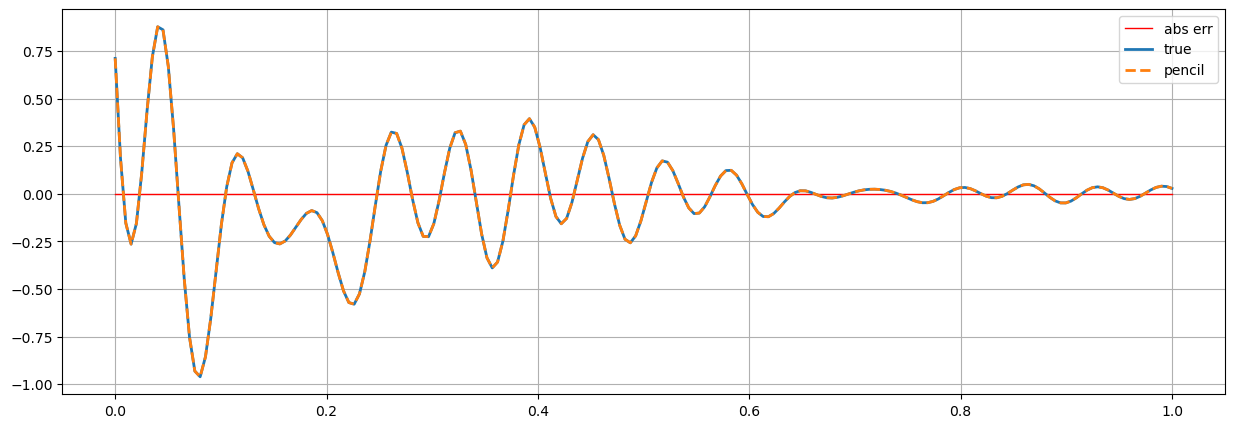

In [40]:
plt.figure(figsize=(15,5))
plt.plot(ts,np.abs(sig-signal(ts,params_est)),label='abs err',color='red',linewidth=1,alpha=1)

plt.plot(ts,sig,label='true',linewidth=2)
plt.plot(ts,signal(ts,params_est), label='pencil',linewidth=2, linestyle='--')

plt.legend()
plt.grid()
plt.show()

In [41]:
noisy_sig = signal(ts, params, sigma=0.1)
output = pencil(noisy_sig, M=8)
params_est = get_params_pencil(output, dt)
print_params(params_est)

frequency (rad/s)   decay (1/s)         weights             phases (rad)        error               
----------------------------------------------------------------------------------------------------
-1.09151E+01        -1.08885E+01        6.99196E-01         -9.80849E-01        NAN                 
1.09151E+01         -1.08885E+01        6.99196E-01         9.80849E-01         NAN                 
9.31714E+01         -3.78038E+00        4.61591E-01         1.52857E+00         NAN                 
-9.31714E+01        -3.78038E+00        4.61591E-01         -1.52857E+00        NAN                 
1.04518E+02         -3.61364E+00        2.24723E-01         2.79491E+00         NAN                 
-1.04518E+02        -3.61364E+00        2.24723E-01         -2.79491E+00        NAN                 
4.50940E+01         -2.58305E+00        1.41497E-01         -2.42829E-01        NAN                 
-4.50940E+01        -2.58305E+00        1.41497E-01         2.42829E-01         NAN        

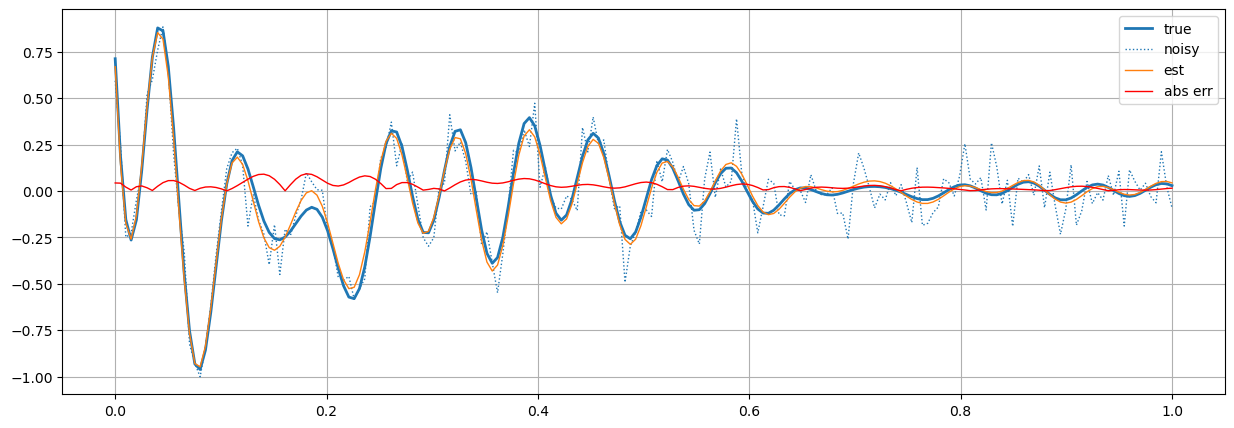

In [42]:
plt.figure(figsize=(15,5))
plt.plot(ts,sig,label='true',linewidth=2, color='C0')
plt.plot(ts,noisy_sig, label='noisy',linewidth=1, linestyle=':', color='C0')
plt.plot(ts,signal(ts,params_est),label='est',color='C1',linewidth=1,alpha=1)
plt.plot(ts,np.abs(sig-signal(ts,params_est)),label='abs err',color='red',linewidth=1,alpha=1)
plt.legend()
plt.grid()
plt.show()

## what if you don't know $M$?

Vary $M$ and find the lowest $M$ at which the error plateaus--this indicates that you have captured most of the true signal.  If you do not observe such behavior, it means that the SNR of your signal is bad.

In [43]:
Ms = np.arange(1,20)
errs = np.arange(len(Ms), dtype=float)
for iM,M in enumerate(Ms):
    output = pencil(noisy_sig, M=M)
    params_est = get_params_pencil(output, dt)
    err = np.linalg.norm(noisy_sig-signal(ts,params_est))
    errs[iM] = err

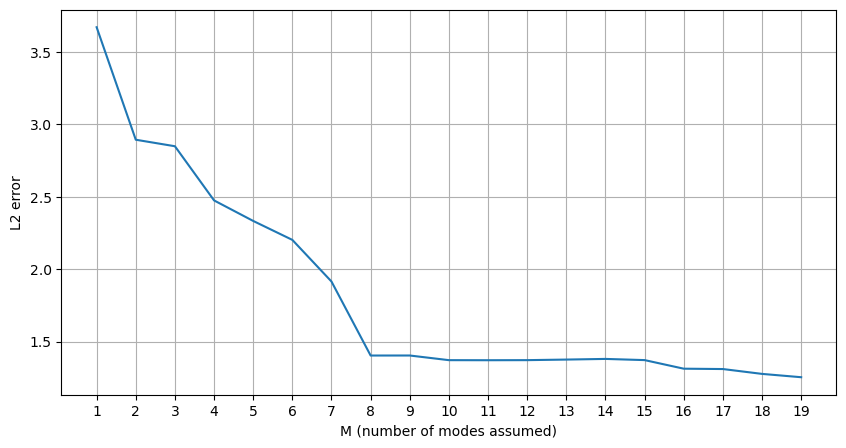

In [44]:
plt.figure(figsize=(10,5))
plt.plot(Ms, errs)
plt.ylabel('L2 error')
# plt.yscale('log')
plt.xlabel('M (number of modes assumed)')
plt.xticks(Ms)
plt.grid()